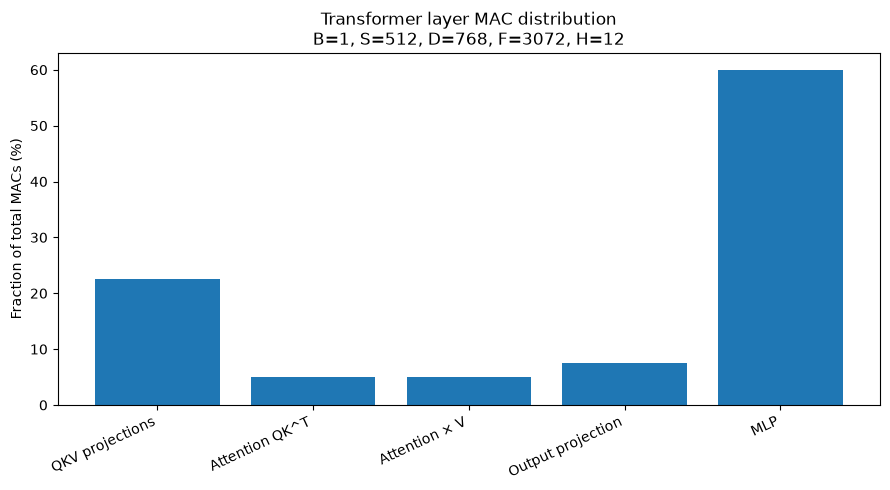

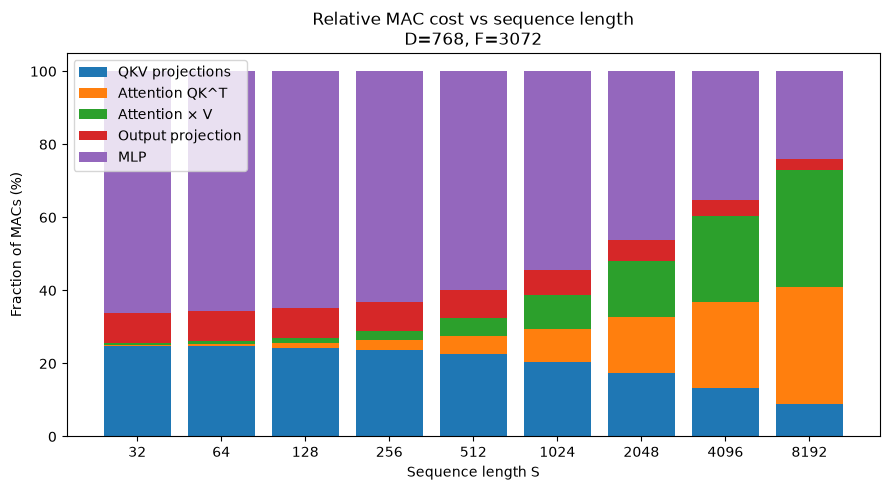

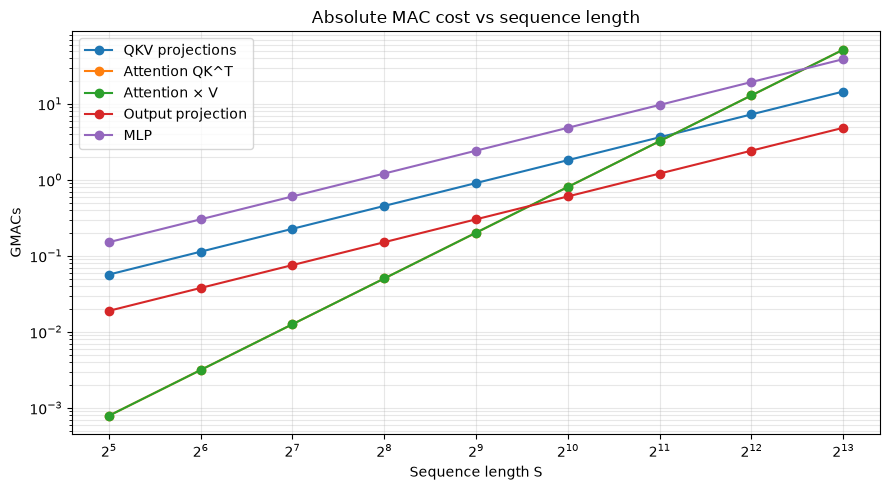

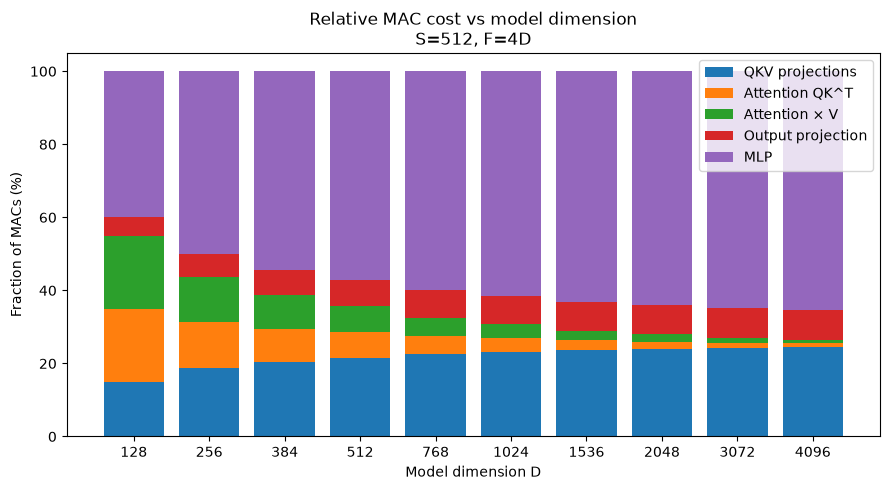

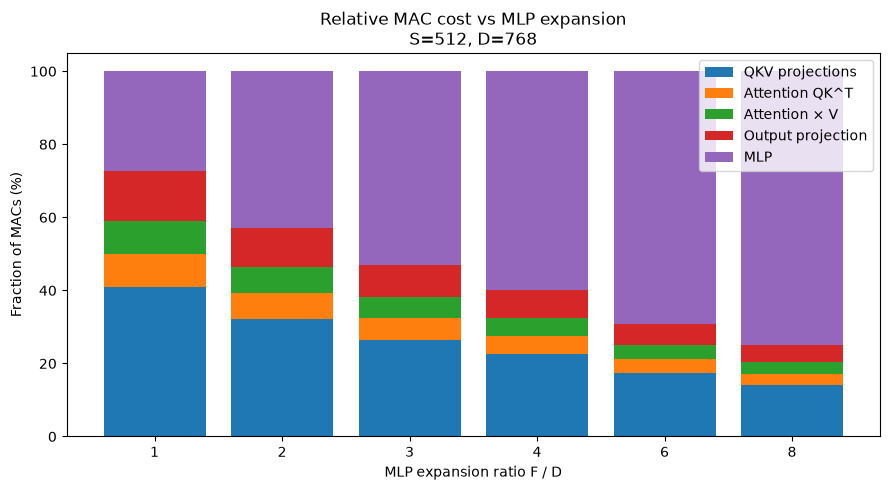

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def transformer_macs(B, S, D, F, H=1):
    """
    MAC counts for one standard Transformer layer.

    B : batch size
    S : sequence length
    D : model/embedding dimension
    F : MLP hidden dimension
    H : number of attention heads

    H does not affect total MAC count when D is fixed.
    """

    assert D % H == 0, "D must be divisible by H"

    macs = {
        "Q projection": B * S * D * D,
        "K projection": B * S * D * D,
        "V projection": B * S * D * D,

        "QK^T": B * S * S * D,
        "Attention × V": B * S * S * D,

        "Output projection": B * S * D * D,

        "MLP up": B * S * D * F,
        "MLP down": B * S * F * D,
    }

    return macs


def grouped_macs(B, S, D, F, H=1):
    m = transformer_macs(B, S, D, F, H)

    return {
        "QKV projections":
            m["Q projection"]
            + m["K projection"]
            + m["V projection"],

        "Attention QK^T":
            m["QK^T"],

        "Attention × V":
            m["Attention × V"],

        "Output projection":
            m["Output projection"],

        "MLP":
            m["MLP up"]
            + m["MLP down"],
    }


def normalize(values):
    values = np.asarray(values)
    return values / values.sum()


# ============================================================
# Baseline configuration
# ============================================================

B = 1
S = 512
D = 768
F = 4 * D
H = 12


# ============================================================
# 1. Relative cost for one configuration
# ============================================================

macs = grouped_macs(B, S, D, F, H)

names = list(macs.keys())
values = np.array(list(macs.values()))
relative = values / values.sum()

plt.figure(figsize=(9, 5))

plt.bar(names, relative * 100)

plt.ylabel("Fraction of total MACs (%)")
plt.title(
    f"Transformer layer MAC distribution\n"
    f"B={B}, S={S}, D={D}, F={F}, H={H}"
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


# ============================================================
# 2. Sweep sequence length
# ============================================================

sequence_lengths = np.array([
    32, 64, 128, 256, 512,
    1024, 2048, 4096, 8192
])

components = list(grouped_macs(B, S, D, F, H).keys())

relative_costs = {
    component: []
    for component in components
}

total_cost = []

for seq in sequence_lengths:

    macs = grouped_macs(
        B=B,
        S=seq,
        D=D,
        F=F,
        H=H
    )

    total = sum(macs.values())
    total_cost.append(total)

    for component in components:
        relative_costs[component].append(
            macs[component] / total
        )


plt.figure(figsize=(9, 5))

bottom = np.zeros(len(sequence_lengths))

for component in components:

    values = np.array(relative_costs[component]) * 100

    plt.bar(
        sequence_lengths.astype(str),
        values,
        bottom=bottom,
        label=component
    )

    bottom += values


plt.xlabel("Sequence length S")
plt.ylabel("Fraction of MACs (%)")
plt.title(
    f"Relative MAC cost vs sequence length\n"
    f"D={D}, F={F}"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 3. Absolute cost vs sequence length
# ============================================================

plt.figure(figsize=(9, 5))

for component in components:

    values = []

    for seq in sequence_lengths:

        macs = grouped_macs(
            B=B,
            S=seq,
            D=D,
            F=F,
            H=H
        )

        values.append(
            macs[component]
        )

    # Convert to GMAC
    values = np.array(values) / 1e9

    plt.plot(
        sequence_lengths,
        values,
        marker="o",
        label=component
    )


plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Sequence length S")
plt.ylabel("GMACs")
plt.title("Absolute MAC cost vs sequence length")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


# ============================================================
# 4. Sweep model dimension D
# ============================================================

dimensions = np.array([
    128, 256, 384, 512,
    768, 1024, 1536, 2048,
    3072, 4096
])

relative_costs = {
    component: []
    for component in components
}


for dim in dimensions:

    f = 4 * dim

    macs = grouped_macs(
        B=B,
        S=S,
        D=dim,
        F=f,
        H=1
    )

    total = sum(macs.values())

    for component in components:

        relative_costs[component].append(
            macs[component] / total
        )


plt.figure(figsize=(9, 5))

bottom = np.zeros(len(dimensions))

for component in components:

    values = np.array(
        relative_costs[component]
    ) * 100

    plt.bar(
        dimensions.astype(str),
        values,
        bottom=bottom,
        label=component
    )

    bottom += values


plt.xlabel("Model dimension D")
plt.ylabel("Fraction of MACs (%)")

plt.title(
    f"Relative MAC cost vs model dimension\n"
    f"S={S}, F=4D"
)

plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 5. Sweep F / D ratio
# ============================================================

ratios = np.array([
    1, 2, 3, 4, 6, 8
])

relative_costs = {
    component: []
    for component in components
}

for ratio in ratios:

    f = int(ratio * D)

    macs = grouped_macs(
        B=B,
        S=S,
        D=D,
        F=f,
        H=H
    )

    total = sum(macs.values())

    for component in components:

        relative_costs[component].append(
            macs[component] / total
        )


plt.figure(figsize=(9, 5))

bottom = np.zeros(len(ratios))

for component in components:

    values = np.array(
        relative_costs[component]
    ) * 100

    plt.bar(
        ratios.astype(str),
        values,
        bottom=bottom,
        label=component
    )

    bottom += values


plt.xlabel("MLP expansion ratio F / D")
plt.ylabel("Fraction of MACs (%)")
plt.title(
    f"Relative MAC cost vs MLP expansion\n"
    f"S={S}, D={D}"
)

plt.legend()
plt.tight_layout()
plt.show()

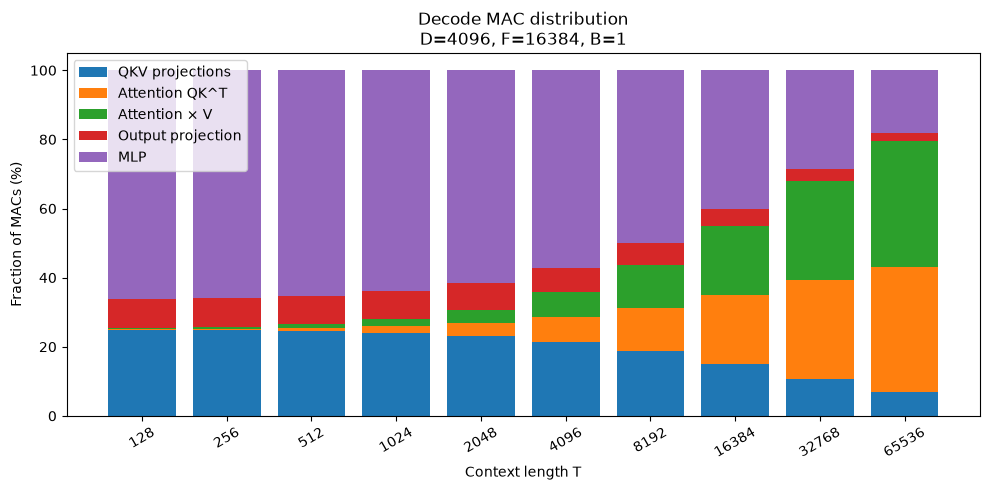

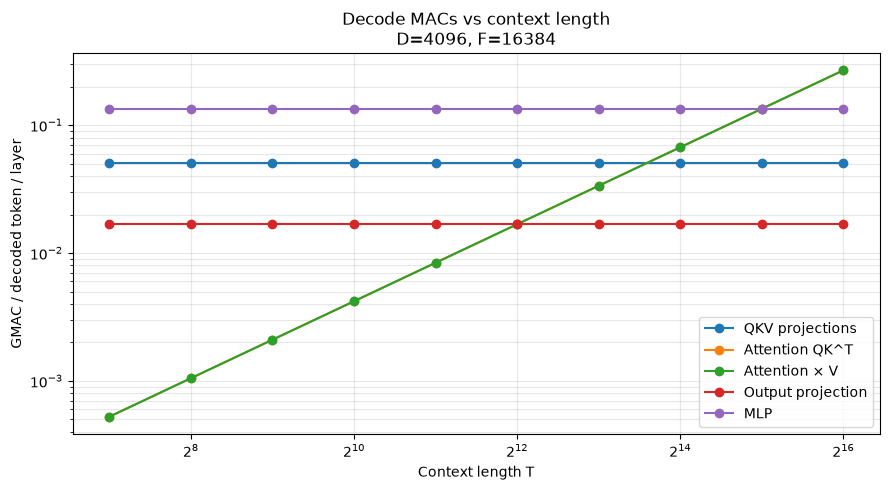

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def decode_macs(B, T, D, F):
    """
    MACs for one Transformer layer
    for one autoregressive decode step with KV cache.
    """

    return {
        "QKV projections": 3 * B * D * D,
        "Attention QK^T": B * T * D,
        "Attention × V": B * T * D,
        "Output projection": B * D * D,
        "MLP": 2 * B * D * F,
    }


# ============================================================
# Baseline
# ============================================================

B = 1
D = 4096
F = 4 * D

context_lengths = np.array([
    128,
    256,
    512,
    1024,
    2048,
    4096,
    8192,
    16384,
    32768,
    65536,
])


# ============================================================
# Relative MAC cost
# ============================================================

components = list(
    decode_macs(B, context_lengths[0], D, F).keys()
)

relative_costs = {
    component: []
    for component in components
}


for T in context_lengths:

    macs = decode_macs(B, T, D, F)

    total = sum(macs.values())

    for component in components:
        relative_costs[component].append(
            macs[component] / total
        )


plt.figure(figsize=(10, 5))

bottom = np.zeros(len(context_lengths))

for component in components:

    values = np.array(relative_costs[component]) * 100

    plt.bar(
        context_lengths.astype(str),
        values,
        bottom=bottom,
        label=component
    )

    bottom += values


plt.xlabel("Context length T")
plt.ylabel("Fraction of MACs (%)")

plt.title(
    f"Decode MAC distribution\n"
    f"D={D}, F={F}, B={B}"
)

plt.legend()
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ============================================================
# Absolute MAC cost
# ============================================================

plt.figure(figsize=(9, 5))

for component in components:

    values = []

    for T in context_lengths:

        macs = decode_macs(B, T, D, F)

        values.append(
            macs[component] / 1e9
        )

    plt.plot(
        context_lengths,
        values,
        marker="o",
        label=component
    )


plt.xscale("log", base=2)
plt.yscale("log")

plt.xlabel("Context length T")
plt.ylabel("GMAC / decoded token / layer")

plt.title(
    f"Decode MACs vs context length\n"
    f"D={D}, F={F}"
)

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()